In [1]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd
import os
from pathlib import Path

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle

from thesis_project.models.keyword_spotting.base_schema import KeyWordSpottingBaseConfig
from thesis_project.models.keyword_spotting.dynamic_schema import DynamicTrainingConfig
from thesis_project.training.key_word_spotting.validate_model import validate_model


#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

In [2]:
BASE_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
BASE_MODEL_CHECKPOINT = BASE_MODEL_DIR + "best_model.pth"
BATCH_SIZE = 64
SEED_FOR_EVAL = 789

VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]

USE_AUGMENTED_VAL_SET = False
if USE_AUGMENTED_VAL_SET:
    # Each val_set uses a single noise file - this gives 6 val_sets with different noise types
    # but the same underlying audio samples (loaded in the same order with shuffle=False)
    NOISE_FILES = [
        "doing_the_dishes.wav",
        "dude_miaowing.wav",
        "exercise_bike.wav",
        "pink_noise.wav",
        "running_tap.wav",
        "white_noise.wav",
    ]
    NUMBER_OF_VAL_SETS = len(NOISE_FILES)


In [3]:
# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    pin_memory = True
    num_workers = 16
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    pin_memory = False
    num_workers = 0
    print("Using MPS")
else:
    device = torch.device("cpu")
    pin_memory = False
    print("Using CPU")

Using MPS


In [4]:
# folder with dynamic model checkpoints
parent_dir = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/"
sweep_folders = [
'one_sided_mse_rf_2_4_6_avg',
#'ce_weighted_rank_rf_2_sub',
'one_sided_mse_rf_2_4_6_sub',
#'avg_rank_rf_2_sub',
'batch_mean_mse_rf_2_sub'
]
experiment_folders = []
for sweep in sweep_folders:
    sweep_dir = os.path.join(parent_dir, sweep)
    if os.path.isdir(sweep_dir):
        for exp in os.listdir(sweep_dir):
            exp_path = os.path.join(sweep_dir, exp)
            if os.path.isdir(exp_path):
                experiment_folders.append(exp_path)
experiment_folders.sort(key=lambda x: os.path.getmtime(x), reverse=False)

In [5]:
experiment_folders.sort(key=lambda x: os.path.getmtime(x), reverse=False)


In [6]:
#Datasets and dataloaders
data_dir = get_data_dir()

# Simple val_loader — always created (used when USE_AUGMENTED_VAL_SET=False)
val_set = SpeechCommandsGoogle(
    root=str(get_data_dir()), 
    subset="validation", 
    download=True, 
    seed=SEED_FOR_EVAL,
    noise_prob=1
)
val_loader = DataLoader(
    val_set, 
    batch_size=BATCH_SIZE,
    shuffle=False, 
    pin_memory=pin_memory,
    num_workers=num_workers
)
print(f"Simple val_loader ready: {len(val_set)} samples")

if USE_AUGMENTED_VAL_SET:
    # Factory function to create per-noise-file validation loaders on demand (avoids memory issues).
    # Each val_set uses a single noise file so samples are loaded in the same order
    # but with different noise types — consistent sample IDs across val_sets.
    def create_val_loader(val_set_id: int):
        """Create a validation loader for the given val_set_id.
        Each val_set uses a single noise file, so samples are loaded in the same order
        but with different noise types. This allows consistent sample IDs across val_sets."""
        noise_file = NOISE_FILES[val_set_id]
        _val_set = SpeechCommandsGoogle(
            root=str(data_dir), 
            subset="validation", 
            download=True, 
            **noise_eval_cfg.model_dump(),
            noise_files=[noise_file],  # Single noise file for this val_set
            seed=SEED_FOR_EVAL,  # Same seed for all val_sets - consistent sample ordering
        )
        _val_loader = DataLoader(_val_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory, num_workers=num_workers)
        return _val_loader, noise_file

    print(f"Augmented val_loader factory ready. {NUMBER_OF_VAL_SETS} noise files:")
    for i, nf in enumerate(NOISE_FILES):
        print(f"  val_set_id={i}: {nf}")


Adding noise: 100%|██████████| 4515/4515 [00:12<00:00, 375.09sample/s]

Simple val_loader ready: 4515 samples


In [7]:
base_model = KWSBase(cfg).to(device)
base_model.load_state_dict(torch.load(BASE_MODEL_CHECKPOINT, map_location=device))

# print the model architecture and number of parameters
n_total = sum(p.numel() for p in base_model.parameters())
print(f"Base model parameters: {n_total}")

Base model parameters: 338718


In [8]:
def load_sweep_model_checkpoint(
    exp_dir: Union[str, os.PathLike],
    base_model: KWSBase,
    device_override: Optional[torch.device] = None,
) -> Tuple[KWSDynamic, Dict[str, Any]]:
    """
    Load a trained dynamic model from a sweep experiment folder.
    
    Args:
        exp_dir: Path to experiment folder containing best_model.pth and config.json
        base_model: Pre-loaded KWSBase model instance
        device_override: Optional device to override default device

    Expected files inside exp_dir:
      - best_model.pth
      - config.json
    """
    exp_path = Path(exp_dir)
    config_path = exp_path / "config.json"
    checkpoint_path = exp_path / "best_model.pth"

    if not config_path.exists():
        raise FileNotFoundError(f"Missing config file: {config_path}")
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint file: {checkpoint_path}")

    # Resolve device
    _device = device_override if device_override is not None else device

    # 1) Load dynamic training config
    with open(config_path, "r") as f:
        config_dict = json.load(f)
    full_config = DynamicTrainingConfig(**config_dict)

    # 2) Build router from config
    base_model_full_rank = min(
        base_model.cfg.backbone.n_channels_ext,
        base_model.cfg.backbone.n_channels_int,
    )
    maximum_useful_rank = base_model_full_rank // 2

    router = GRURouter(
        input_dim=base_model.frontend.out_channels,
        gru_hidden_dim=full_config.router.hidden_dim,
        num_gru_layers=full_config.router.num_gru_layers,
        max_rank=maximum_useful_rank,
        num_rank_outputs=full_config.router.num_rank_outputs,
        last_layer_bias_init=full_config.router.last_layer_bias_init,
        pool_type=full_config.router.pool_mode,
        pool_reduction_factor=full_config.router.pool_reduction_factor,
    )

    # 3) Instantiate dynamic model
    dynamic_model = KWSDynamic(
        base=base_model,
        router=router,
        use_global_rank=full_config.router.use_global_rank,
        low_rank_frontend=full_config.dynamic_model.low_rank_frontend,
        freeze_base=full_config.dynamic_model.freeze_base,
    ).to(_device)

    # 4) Load trained dynamic checkpoint (handle multiple formats)
    checkpoint = torch.load(checkpoint_path, map_location=_device)
    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        elif "model_state" in checkpoint:
            state_dict = checkpoint["model_state"]
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    dynamic_model.load_state_dict(state_dict)
    dynamic_model.eval()

    print(f"Loaded dynamic model from: {checkpoint_path}")
    return dynamic_model, config_dict

In [9]:
print(f"Found {len(experiment_folders)} dynamic experiment folders")
for exp_dir in experiment_folders[:5]:
    print(f"  {exp_dir}")

if experiment_folders:
    print(f"\nFirst experiment folder: {experiment_folders[0]}")


Found 210 dynamic experiment folders
  /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/one_sided_mse_rf_2_4_6_sub/exp_001
  /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/one_sided_mse_rf_2_4_6_sub/exp_002
  /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/one_sided_mse_rf_2_4_6_sub/exp_003
  /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/one_sided_mse_rf_2_4_6_sub/exp_004
  /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/one_sided_mse_rf_2_4_6_sub/exp_005

First experiment folder: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/one_sided_mse_rf_2_4_6_sub/exp_001


In [10]:
def evaluate_dynamic_model(
    model: KWSDynamic,
    val_loader_factory,  # Callable[[int], Tuple[DataLoader, str]]
    num_val_sets: int,
    criterion: nn.Module,
    device: torch.device,
    *,
    snr_values=None,
    max_rank: int = 64,
    verbose: bool = True,
) -> Tuple[Dict, pd.DataFrame]:
    """
    Evaluate a dynamic model across multiple validation sets (one per noise file).

    The dynamic model predicts ranks via its router — there are no fixed ranks to sweep.
    Each val_set uses a different noise file but the same underlying audio samples,
    allowing consistent sample IDs across noise conditions.

    Args:
        model: KWSDynamic model to evaluate
        val_loader_factory: Callable(val_set_id) -> (DataLoader, noise_file_name)
        num_val_sets: Number of validation sets (one per noise file)
        criterion: Loss function
        device: Device to run on
        snr_values: SNR values to evaluate. If None, uses VAL_SNR_VALUES
        max_rank: Max rank used for computing expected_rank in validate_model
        verbose: If True, print progress and results

    Returns:
        aggregate_results:
            dict with keys: "loss", "acc", "mean_rank_normalized", "expected_rank",
            "mean_r_stacks" (list, one value per stack), "per_snr_results"
            All metrics averaged across all validation sets and SNRs.

        per_sample_df:
            DataFrame with per-sample predictions. Columns include:
              snr_eval, rank, rank_normalized, pred, target, correct,
              val_set_id, noise_file, and optional metadata (label, utterance, noise_type)
    """
    import gc

    if snr_values is None:
        snr_values = VAL_SNR_VALUES

    model.eval()

    def snr_to_key(snr):
        return "snr_inf" if snr == float('inf') else f"snr_{snr}"

    snr_keys = [snr_to_key(snr) for snr in snr_values]

    results_by_val_set: List[Dict] = []
    all_sample_records: List[Dict[str, Any]] = []

    for val_set_id in range(num_val_sets):
        if verbose:
            print(f"\n{'='*60}")
            print(f"Validation set {val_set_id + 1}/{num_val_sets}...")

        val_loader, noise_file = val_loader_factory(val_set_id)

        if verbose:
            print(f"  Noise file: {noise_file}")

        agg_results, per_sample_records = validate_model(
            model,
            val_loader,
            criterion,
            device,
            snr_values=snr_values,
            verbose=False,
            is_dynamic=True,
            max_rank=max_rank,
            return_per_sample=True,
            compute_loss=False,
        )

        results_by_val_set.append(agg_results.get("per_snr_results", {}))

        for rec in per_sample_records:
            rec["val_set_id"] = val_set_id
            rec["noise_file"] = noise_file
        all_sample_records.extend(per_sample_records)

        if verbose:
            per_snr = results_by_val_set[-1]
            parts = []
            for snr_key in snr_keys:
                if snr_key in per_snr:
                    s = per_snr[snr_key]
                    part = f"{snr_key}: acc={s['acc']:.1f}%"
                    if "expected_rank" in s:
                        part += f" exp_r={s['expected_rank']:.1f}"
                    if "mean_r_stacks" in s:
                        stacks_str = "[" + ", ".join(f"{r:.1f}" for r in s["mean_r_stacks"]) + "]"
                        part += f" r_stacks={stacks_str}"
                    parts.append(part)
            print("  " + ", ".join(parts))

        del val_loader
        gc.collect()

    def _avg_metric(values):
        """Average a list of metric values — handles both scalars and equal-length lists."""
        if isinstance(values[0], list):
            # Element-wise average across val_sets (e.g. mean_r_stacks)
            return [float(np.mean([v[i] for v in values])) for i in range(len(values[0]))]
        return float(np.mean(values))

    # Average per-snr metrics across all val_sets
    final_per_snr: Dict[str, Dict] = {}
    for snr_key in snr_keys:
        metric_lists: Dict[str, list] = {}
        for val_results in results_by_val_set:
            if snr_key not in val_results:
                continue
            for metric, val in val_results[snr_key].items():
                metric_lists.setdefault(metric, []).append(val)
        final_per_snr[snr_key] = {k: _avg_metric(v) for k, v in metric_lists.items()}

    if verbose:
        print(f"\n{'='*60}")
        print(f"=== Final Results (averaged over {num_val_sets} noise files) ===")
        for snr_key in snr_keys:
            if snr_key in final_per_snr:
                s = final_per_snr[snr_key]
                msg = f"{snr_key}: acc={s['acc']:.2f}%  loss={s['loss']:.4f}"
                if "expected_rank" in s:
                    msg += f"  exp_rank={s['expected_rank']:.2f}"
                if "mean_r_stacks" in s:
                    stacks_str = "[" + ", ".join(f"{r:.1f}" for r in s["mean_r_stacks"]) + "]"
                    msg += f"  r_stacks={stacks_str}"
                print(msg)
        print("-" * 60)

    # Build top-level aggregate (mean across SNRs)
    aggregate_results: Dict[str, Any] = {
        "loss": float(np.mean([s["loss"] for s in final_per_snr.values()])),
        "acc": float(np.mean([s["acc"] for s in final_per_snr.values()])),
        "per_snr_results": final_per_snr,
    }
    for metric in ("mean_rank_normalized", "expected_rank", "rank_loss_weighted"):
        vals = [s[metric] for s in final_per_snr.values() if metric in s]
        if vals:
            aggregate_results[metric] = float(np.mean(vals))

    # mean_r_stacks: average element-wise across SNRs
    stack_vals = [s["mean_r_stacks"] for s in final_per_snr.values() if "mean_r_stacks" in s]
    if stack_vals:
        aggregate_results["mean_r_stacks"] = [
            float(np.mean([v[i] for v in stack_vals])) for i in range(len(stack_vals[0]))
        ]

    per_sample_df = pd.DataFrame(all_sample_records)
    return aggregate_results, per_sample_df

In [11]:
criterion = nn.CrossEntropyLoss()  # doesn't matter — compute_loss=False


def to_serializable(obj):
    if isinstance(obj, dict):
        return {key: to_serializable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_serializable(value) for value in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    return obj


def save_evaluation_outputs(exp_dir, aggregate_results, per_sample_df):
    exp_path = Path(exp_dir)
    aggregate_path = exp_path / "aggregate_results.json"
    per_sample_path = exp_path / "per_sample_df.csv"

    with open(aggregate_path, "w") as f:
        json.dump(to_serializable(aggregate_results), f, indent=2)

    per_sample_df.to_csv(per_sample_path, index=False)
    return aggregate_path, per_sample_path


results_overview = []
aggregate_results = None
per_sample_df = None

if not experiment_folders:
    raise ValueError("No experiment folders found.")

for exp_idx, exp_dir in enumerate(experiment_folders, start=1):
    exp_path = Path(exp_dir)
    print(f"\n{'#' * 80}")
    print(f"[{exp_idx}/{len(experiment_folders)}] Evaluating {exp_path.name}")

    dyn_model, config_dict = load_sweep_model_checkpoint(exp_dir, base_model)

    if USE_AUGMENTED_VAL_SET:
        aggregate_results, per_sample_df = evaluate_dynamic_model(
            dyn_model,
            create_val_loader,
            NUMBER_OF_VAL_SETS,
            criterion,
            device,
            snr_values=VAL_SNR_VALUES,
            max_rank=64,
            verbose=True,
        )
    else:
        agg_results, per_sample_records = validate_model(
            dyn_model,
            val_loader,
            criterion,
            device,
            snr_values=VAL_SNR_VALUES,
            verbose=True,
            is_dynamic=True,
            max_rank=64,
            return_per_sample=True,
            compute_loss=False,
        )
        aggregate_results = agg_results
        per_sample_df = pd.DataFrame(per_sample_records)

    aggregate_path, per_sample_path = save_evaluation_outputs(exp_dir, aggregate_results, per_sample_df)
    print(f"Saved aggregate results to: {aggregate_path}")
    print(f"Saved per-sample results to: {per_sample_path}")

    results_overview.append(
        {
            "experiment_name": exp_path.name,
            "experiment_dir": str(exp_path),
            "acc": float(aggregate_results.get("acc", np.nan)),
            "loss": float(aggregate_results.get("loss", np.nan)),
            "expected_rank": float(aggregate_results.get("expected_rank", np.nan)),
            "mean_rank_normalized": float(aggregate_results.get("mean_rank_normalized", np.nan)),
            "n_samples": int(len(per_sample_df)),
        }
    )

results_overview_df = pd.DataFrame(results_overview)
results_overview_df


/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/components/layers/cpc.py:42: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vt = torch.linalg.svd(W, full_matrices=False)



################################################################################
[1/210] Evaluating exp_001
Loaded dynamic model from: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/one_sided_mse_rf_2_4_6_sub/exp_001/best_model.pth


SNR=-5: loss=0.0000, acc=77.43%, exp_rank=28.94, rank_loss_weighted=0.0000, r_stacks=[28.9]


SNR=0: loss=0.0000, acc=85.67%, exp_rank=25.53, rank_loss_weighted=0.0000, r_stacks=[25.5]


SNR=5: loss=0.0000, acc=89.15%, exp_rank=23.58, rank_loss_weighted=0.0000, r_stacks=[23.6]


...

SNR=5: loss=0.0000, acc=90.08%, exp_rank=27.62, rank_loss_weighted=0.0000, r_stacks=[27.5,23.9,31.5]


SNR=10: loss=0.0000, acc=91.50%, exp_rank=25.93, rank_loss_weighted=0.0000, r_stacks=[25.7,22.0,30.1]


SNR=15: loss=0.0000, acc=92.74%, exp_rank=25.12, rank_loss_weighted=0.0000, r_stacks=[24.9,21.0,29.5]


SNR=inf: loss=0.0000, acc=93.64%, exp_rank=25.16, rank_loss_weighted=0.0000, r_stacks=[25.2,21.4,28.9]
Saved aggregate results to: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/batch_mean_mse_rf_2_sub/exp_030/aggregate_results.json
Saved per-sample results to: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/batch_mean_mse_rf_2_sub/exp_030/per_sample_df.csv


,experiment_name,experiment_dir,acc,loss,expected_rank,mean_rank_normalized,n_samples
0,exp_001,/Users/christoffer/Documents/Thesis/thesis_pro...,88.183832,0.0,24.471835,0.372569,27090
1,exp_002,/Users/christoffer/Documents/Thesis/thesis_pro...,88.449612,0.0,25.124047,0.382921,27090
2,exp_003,/Users/christoffer/Documents/Thesis/thesis_pro...,89.202658,0.0,29.210752,0.447790,27090
3,exp_004,/Users/christoffer/Documents/Thesis/thesis_pro...,89.114064,0.0,28.474061,0.436096,27090
4,exp_005,/Users/christoffer/Documents/Thesis/thesis_pro...,89.534884,0.0,33.238191,0.511717,27090
...,...,...,...,...,...,...,...
205,exp_026,/Users/christoffer/Documents/Thesis/thesis_pro...,79.656700,0.0,13.693588,0.201486,27090
206,exp_027,/Users/christoffer/Documents/Thesis/thesis_pro...,84.780362,0.0,19.800871,0.298427,27090
207,exp_028,/Users/christoffer/Documents/Thesis/thesis_pro...,85.836102,0.0,19.729460,0.297293,27090
208,exp_029,/Users/christoffer/Documents/Thesis/thesis_pro...,88.719085,0.0,28.591818,0.437965,27090


In [12]:
results_overview_df if 'results_overview_df' in globals() else per_sample_df

,experiment_name,experiment_dir,acc,loss,expected_rank,mean_rank_normalized,n_samples
0,exp_001,/Users/christoffer/Documents/Thesis/thesis_pro...,88.183832,0.0,24.471835,0.372569,27090
1,exp_002,/Users/christoffer/Documents/Thesis/thesis_pro...,88.449612,0.0,25.124047,0.382921,27090
2,exp_003,/Users/christoffer/Documents/Thesis/thesis_pro...,89.202658,0.0,29.210752,0.447790,27090
3,exp_004,/Users/christoffer/Documents/Thesis/thesis_pro...,89.114064,0.0,28.474061,0.436096,27090
4,exp_005,/Users/christoffer/Documents/Thesis/thesis_pro...,89.534884,0.0,33.238191,0.511717,27090
...,...,...,...,...,...,...,...
205,exp_026,/Users/christoffer/Documents/Thesis/thesis_pro...,79.656700,0.0,13.693588,0.201486,27090
206,exp_027,/Users/christoffer/Documents/Thesis/thesis_pro...,84.780362,0.0,19.800871,0.298427,27090
207,exp_028,/Users/christoffer/Documents/Thesis/thesis_pro...,85.836102,0.0,19.729460,0.297293,27090
208,exp_029,/Users/christoffer/Documents/Thesis/thesis_pro...,88.719085,0.0,28.591818,0.437965,27090


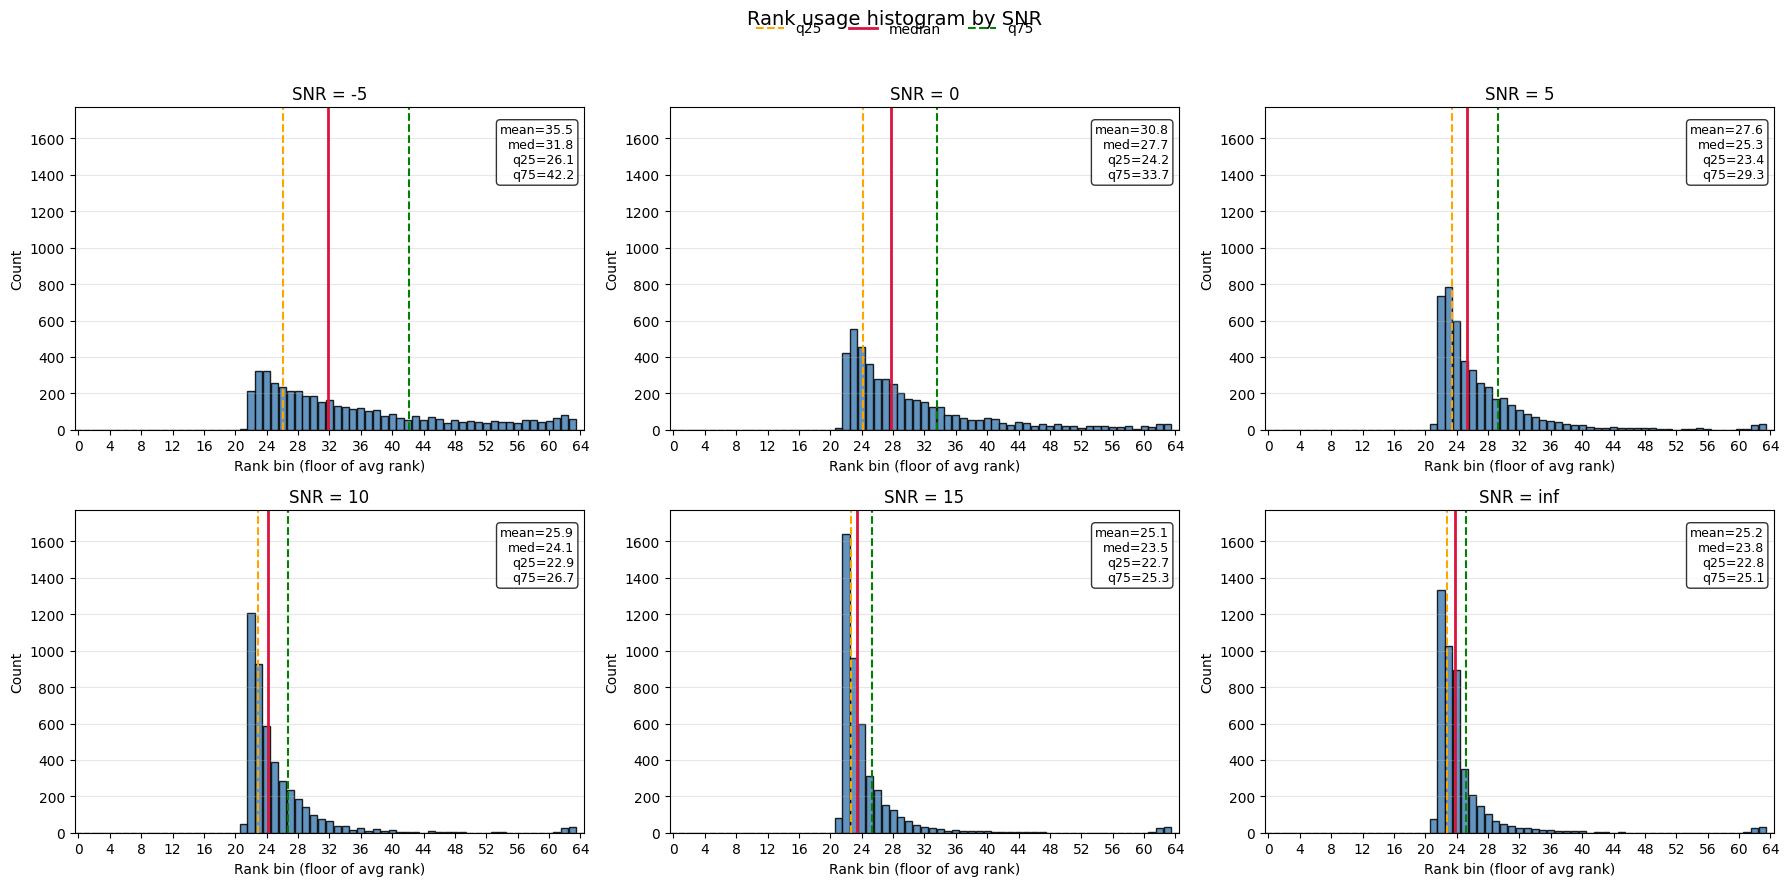

,snr,count,mean,std,min,q10,q25,median,q75,q90,max
0,-5.0,4515,35.52,11.64,21.82,23.70,26.08,31.81,42.19,55.56,63.67
1,0.0,4515,30.79,9.15,21.85,23.04,24.23,27.68,33.66,43.89,63.67
2,5.0,4515,27.62,6.90,21.65,22.69,23.37,25.26,29.28,34.66,63.67
3,10.0,4515,25.93,5.86,21.60,22.46,22.91,24.11,26.73,30.57,63.67
4,15.0,4515,25.12,5.57,21.71,22.31,22.68,23.45,25.31,28.68,63.67
5,inf,4515,25.16,5.50,21.50,22.33,22.78,23.83,25.15,28.27,63.67


In [13]:
import ast
import math


if "per_sample_df" not in globals() or per_sample_df is None or per_sample_df.empty:
    print("No per-sample dataframe is available to plot.")
else:
    def rank_to_scalar(rank_value):
        """Convert rank to a scalar.

        - scalar rank -> float(rank)
        - multiple ranks -> average them
        - stringified list -> parse and average
        """
        if rank_value is None:
            return np.nan

        if isinstance(rank_value, str):
            rank_value = rank_value.strip()
            if not rank_value:
                return np.nan
            if rank_value.startswith("[") and rank_value.endswith("]"):
                try:
                    rank_value = ast.literal_eval(rank_value)
                except (ValueError, SyntaxError):
                    return np.nan

        if isinstance(rank_value, (list, tuple, np.ndarray)):
            rank_array = np.asarray(rank_value, dtype=float).reshape(-1)
            if rank_array.size == 0:
                return np.nan
            return float(rank_array.mean())

        if pd.isna(rank_value):
            return np.nan

        return float(rank_value)


    rank_hist_df = per_sample_df.copy()
    rank_hist_df["rank_scalar"] = rank_hist_df["rank"].apply(rank_to_scalar)
    rank_hist_df = rank_hist_df.dropna(subset=["snr_eval", "rank_scalar"]).copy()
    rank_hist_df["rank_bin"] = rank_hist_df["rank_scalar"].apply(lambda x: int(math.floor(x)))
    rank_hist_df = rank_hist_df[(rank_hist_df["rank_bin"] >= 0) & (rank_hist_df["rank_bin"] <= 64)].copy()

    snr_order = VAL_SNR_VALUES if "VAL_SNR_VALUES" in globals() else sorted(rank_hist_df["snr_eval"].dropna().unique())
    available_snrs = [snr for snr in snr_order if snr in set(rank_hist_df["snr_eval"])]
    all_rank_bins = np.arange(65)
    quantile_levels = [0.1, 0.25, 0.5, 0.75, 0.9]

    if not available_snrs:
        print("No per-sample rank data available to plot.")
    else:
        counts_by_snr = {}
        quantiles_by_snr = {}
        summary_rows = []

        for snr in available_snrs:
            snr_df = rank_hist_df[rank_hist_df["snr_eval"] == snr]
            rank_values = snr_df["rank_scalar"]
            counts_by_snr[snr] = snr_df["rank_bin"].value_counts().reindex(all_rank_bins, fill_value=0)

            quantiles = rank_values.quantile(quantile_levels)
            quantiles_by_snr[snr] = quantiles
            summary_rows.append(
                {
                    "snr": snr,
                    "count": int(rank_values.shape[0]),
                    "mean": float(rank_values.mean()),
                    "std": float(rank_values.std()),
                    "min": float(rank_values.min()),
                    "q10": float(quantiles.loc[0.1]),
                    "q25": float(quantiles.loc[0.25]),
                    "median": float(quantiles.loc[0.5]),
                    "q75": float(quantiles.loc[0.75]),
                    "q90": float(quantiles.loc[0.9]),
                    "max": float(rank_values.max()),
                }
            )

        global_y_max = max(int(counts.max()) for counts in counts_by_snr.values())

        n_cols = min(3, len(available_snrs))
        n_rows = int(np.ceil(len(available_snrs) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), squeeze=False)
        axes_flat = axes.flatten()

        for plot_idx, (ax, snr) in enumerate(zip(axes_flat, available_snrs)):
            counts = counts_by_snr[snr]
            quantiles = quantiles_by_snr[snr]

            ax.bar(counts.index, counts.values, width=0.9, color="steelblue", edgecolor="black", alpha=0.85)
            ax.axvline(quantiles.loc[0.25], color="orange", linestyle="--", linewidth=1.5, label="q25" if plot_idx == 0 else None)
            ax.axvline(quantiles.loc[0.5], color="crimson", linestyle="-", linewidth=2.0, label="median" if plot_idx == 0 else None)
            ax.axvline(quantiles.loc[0.75], color="green", linestyle="--", linewidth=1.5, label="q75" if plot_idx == 0 else None)

            ax.set_title(f"SNR = {snr}")
            ax.set_xlabel("Rank bin (floor of avg rank)")
            ax.set_ylabel("Count")
            ax.set_xlim(-0.5, 64.5)
            ax.set_ylim(0, global_y_max * 1.08)
            ax.set_xticks(np.arange(0, 65, 4))
            ax.grid(axis="y", alpha=0.3)
            ax.text(
                0.98,
                0.95,
                f"mean={rank_hist_df.loc[rank_hist_df['snr_eval'] == snr, 'rank_scalar'].mean():.1f}\n"
                f"med={quantiles.loc[0.5]:.1f}\n"
                f"q25={quantiles.loc[0.25]:.1f}\n"
                f"q75={quantiles.loc[0.75]:.1f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
            )

        for ax in axes_flat[len(available_snrs):]:
            ax.axis("off")

        handles, labels = axes_flat[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.98))

        fig.suptitle("Rank usage histogram by SNR", fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        rank_summary_df = pd.DataFrame(summary_rows).round(2)
        display(rank_summary_df)
